In [1]:
import pandas as pd
from pathlib import Path

data_dir = Path('../core/data/kualitas_udara')
csv_files = sorted(data_dir.glob('*.csv'))

df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
df['datetime'] = df['datetime'].dt.tz_convert('Asia/Jakarta')
df = df.sort_values('datetime').reset_index(drop=True)

print(f'Dataset loaded: {len(df)} rows, {df["datetime"].min()} to {df["datetime"].max()}')

Dataset loaded: 2971 rows, 2025-10-10 15:00:00+07:00 to 2026-05-19 20:00:00+07:00


In [2]:
# 1. Missing value per kolom
print('=== Missing Values per Kolom ===')
missing = df.isna().sum()
print(missing[missing > 0].to_string() if missing.sum() > 0 else 'Tidak ada missing values')

# 2. Cek gap di datetime (harusnya per jam)
full_range = pd.date_range(start=df['datetime'].min(), end=df['datetime'].max(), freq='h', tz='Asia/Jakarta')
existing = df['datetime'].drop_duplicates()
gaps = full_range[~full_range.isin(existing)]

print(f'\n=== Gap pada Datetime ===')
print(f'Range: {full_range[0]} s/d {full_range[-1]}')
print(f'Seharusnya: {len(full_range)} jam')
print(f'Ada di data: {len(existing)} jam')
print(f'Gap (hilang): {len(gaps)} jam')

if len(gaps) > 0:
    gap_groups = []
    current = [gaps[0]]
    for g in gaps[1:]:
        if g == current[-1] + pd.Timedelta(hours=1):
            current.append(g)
        else:
            gap_groups.append(current)
            current = [g]
    gap_groups.append(current)

    print(f'\nTotal segmen gap: {len(gap_groups)}')
    print(f'\n5 Gap terpanjang:')
    gap_sorted = sorted(gap_groups, key=len, reverse=True)[:5]
    for g in gap_sorted:
        durasi = len(g)
        print(f'  {g[0]} s/d {g[-1]}  |  {durasi} jam ({durasi/24:.1f} hari)')

    # Kategorisasi
    panjang = sum(1 for g in gap_groups if len(g) >= 24)
    pendek = sum(1 for g in gap_groups if len(g) < 24)
    print(f'\nKesimpulan:')
    print(f'  Gap panjang (>=1 hari): {panjang} segmen ({sum(len(g) for g in gap_groups if len(g)>=24)} jam)')
    print(f'  Gap pendek (<1 hari):   {pendek} segmen ({sum(len(g) for g in gap_groups if len(g)<24)} jam)')

=== Missing Values per Kolom ===
pm1                   1
pm25                  1
relativehumidity    105
temperature         105
um003                 1

=== Gap pada Datetime ===
Range: 2025-10-10 15:00:00+07:00 s/d 2026-05-19 20:00:00+07:00
Seharusnya: 5310 jam
Ada di data: 2971 jam
Gap (hilang): 2339 jam

Total segmen gap: 48

5 Gap terpanjang:
  2025-11-28 00:00:00+07:00 s/d 2025-12-16 13:00:00+07:00  |  446 jam (18.6 hari)
  2025-10-22 16:00:00+07:00 s/d 2025-11-03 11:00:00+07:00  |  284 jam (11.8 hari)
  2025-12-29 17:00:00+07:00 s/d 2026-01-07 19:00:00+07:00  |  219 jam (9.1 hari)
  2025-11-12 13:00:00+07:00 s/d 2025-11-21 14:00:00+07:00  |  218 jam (9.1 hari)
  2026-01-12 15:00:00+07:00 s/d 2026-01-18 15:00:00+07:00  |  145 jam (6.0 hari)

Kesimpulan:
  Gap panjang (>=1 hari): 16 segmen (2171 jam)
  Gap pendek (<1 hari):   32 segmen (168 jam)


In [3]:
# Cari segmen data kontinu 7 hari (168 jam) tanpa putus
df_sorted = df.sort_values('datetime').reset_index(drop=True)
df_sorted['hour_diff'] = df_sorted['datetime'].diff().dt.total_seconds() / 3600

# Tandai awal segmen baru jika gap > 1 jam
df_sorted['segmen_baru'] = df_sorted['hour_diff'].fillna(1) > 1
df_sorted['segmen_id'] = df_sorted['segmen_baru'].cumsum()

# Panjang tiap segmen dalam jam
segmen_length = df_sorted.groupby('segmen_id').agg(
    start=('datetime', 'first'),
    end=('datetime', 'last'),
    total_jam=('datetime', 'count')
).reset_index()
segmen_length['total_hari'] = (segmen_length['total_jam'] / 24).round(1)

# Filter segmen >= 7 hari (168 jam)
segs_7 = segmen_length[segmen_length['total_jam'] >= 168].copy()

print(f'Total segmen data kontinu: {len(segmen_length)}')
print(f'Segmen dengan >= 7 hari penuh: {len(segs_7)}')
print()

if len(segs_7) > 0:
    for _, r in segs_7.iterrows():
        print(f'  Segmen #{r["segmen_id"]}: {r["start"]} s/d {r["end"]}')
        print(f'    Durasi: {r["total_jam"]} jam ({r["total_hari"]} hari)')
        print()
else:
    print('Tidak ada segmen 7 hari penuh tanpa putus.')

Total segmen data kontinu: 49
Segmen dengan >= 7 hari penuh: 5

  Segmen #33: 2026-01-20 01:00:00+07:00 s/d 2026-01-30 16:00:00+07:00
    Durasi: 256 jam (10.7 hari)

  Segmen #39: 2026-02-27 08:00:00+07:00 s/d 2026-03-07 18:00:00+07:00
    Durasi: 203 jam (8.5 hari)

  Segmen #40: 2026-03-09 15:00:00+07:00 s/d 2026-03-20 21:00:00+07:00
    Durasi: 271 jam (11.3 hari)

  Segmen #41: 2026-03-20 23:00:00+07:00 s/d 2026-04-16 12:00:00+07:00
    Durasi: 638 jam (26.6 hari)

  Segmen #44: 2026-04-24 12:00:00+07:00 s/d 2026-05-06 04:00:00+07:00
    Durasi: 281 jam (11.7 hari)



In [4]:
# Pisahkan tiap segmen 7 hari+ ke dataframe sendiri
segmen_dfs = {}
for _, r in segs_7.iterrows():
    sid = r['segmen_id']
    segmen_dfs[sid] = df_sorted[df_sorted['segmen_id'] == sid].copy()

print(f'{len(segmen_dfs)} segmen (>=7 hari) siap digunakan:')
for sid, sdf in segmen_dfs.items():
    print(f'  segmen_dfs[{sid}]: {len(sdf)} jam ({len(sdf)/24:.1f} hari)')

5 segmen (>=7 hari) siap digunakan:
  segmen_dfs[33]: 256 jam (10.7 hari)
  segmen_dfs[39]: 203 jam (8.5 hari)
  segmen_dfs[40]: 271 jam (11.3 hari)
  segmen_dfs[41]: 638 jam (26.6 hari)
  segmen_dfs[44]: 281 jam (11.7 hari)


In [5]:
# Outlier analysis dengan rolling z-score (window 24 jam) per segmen
for sid, seg in segmen_dfs.items():
    seg = seg.set_index('datetime').sort_index()
    cols = ['pm25', 'pm1', 'temperature', 'relativehumidity', 'um003']

    print(f'Segmen #{sid} ({len(seg)} jam):')

    for col in cols:
        if col not in seg.columns:
            continue
        series = seg[col].dropna()
        rolling_mean = series.rolling(24, min_periods=6).mean()
        rolling_std = series.rolling(24, min_periods=6).std()
        rolling_z = (series - rolling_mean) / rolling_std

        n_outliers = (rolling_z.abs() > 3).sum()
        pct_outliers = (rolling_z.abs() > 3).mean() * 100
        n_ekstrim = (rolling_z.abs() > 5).sum()

        print(f'  {col:20s} |  z>3: {n_outliers:4d} ({pct_outliers:.1f}%)  |  z>5: {n_ekstrim}')

    print()

Segmen #33 (256 jam):
  pm25                 |  z>3:    4 (1.6%)  |  z>5: 0
  pm1                  |  z>3:    3 (1.2%)  |  z>5: 0
  temperature          |  z>3:    0 (0.0%)  |  z>5: 0
  relativehumidity     |  z>3:    3 (1.2%)  |  z>5: 0
  um003                |  z>3:    3 (1.2%)  |  z>5: 0

Segmen #39 (203 jam):
  pm25                 |  z>3:    3 (1.5%)  |  z>5: 0
  pm1                  |  z>3:    3 (1.5%)  |  z>5: 0
  temperature          |  z>3:    5 (2.5%)  |  z>5: 0
  relativehumidity     |  z>3:    1 (0.5%)  |  z>5: 0
  um003                |  z>3:    3 (1.5%)  |  z>5: 0

Segmen #40 (271 jam):
  pm25                 |  z>3:    3 (1.1%)  |  z>5: 0
  pm1                  |  z>3:    5 (1.8%)  |  z>5: 0
  temperature          |  z>3:    4 (1.5%)  |  z>5: 0
  relativehumidity     |  z>3:    1 (0.4%)  |  z>5: 0
  um003                |  z>3:    4 (1.5%)  |  z>5: 0

Segmen #41 (638 jam):
  pm25                 |  z>3:    7 (1.1%)  |  z>5: 0
  pm1                  |  z>3:    8 (1.3%)  |

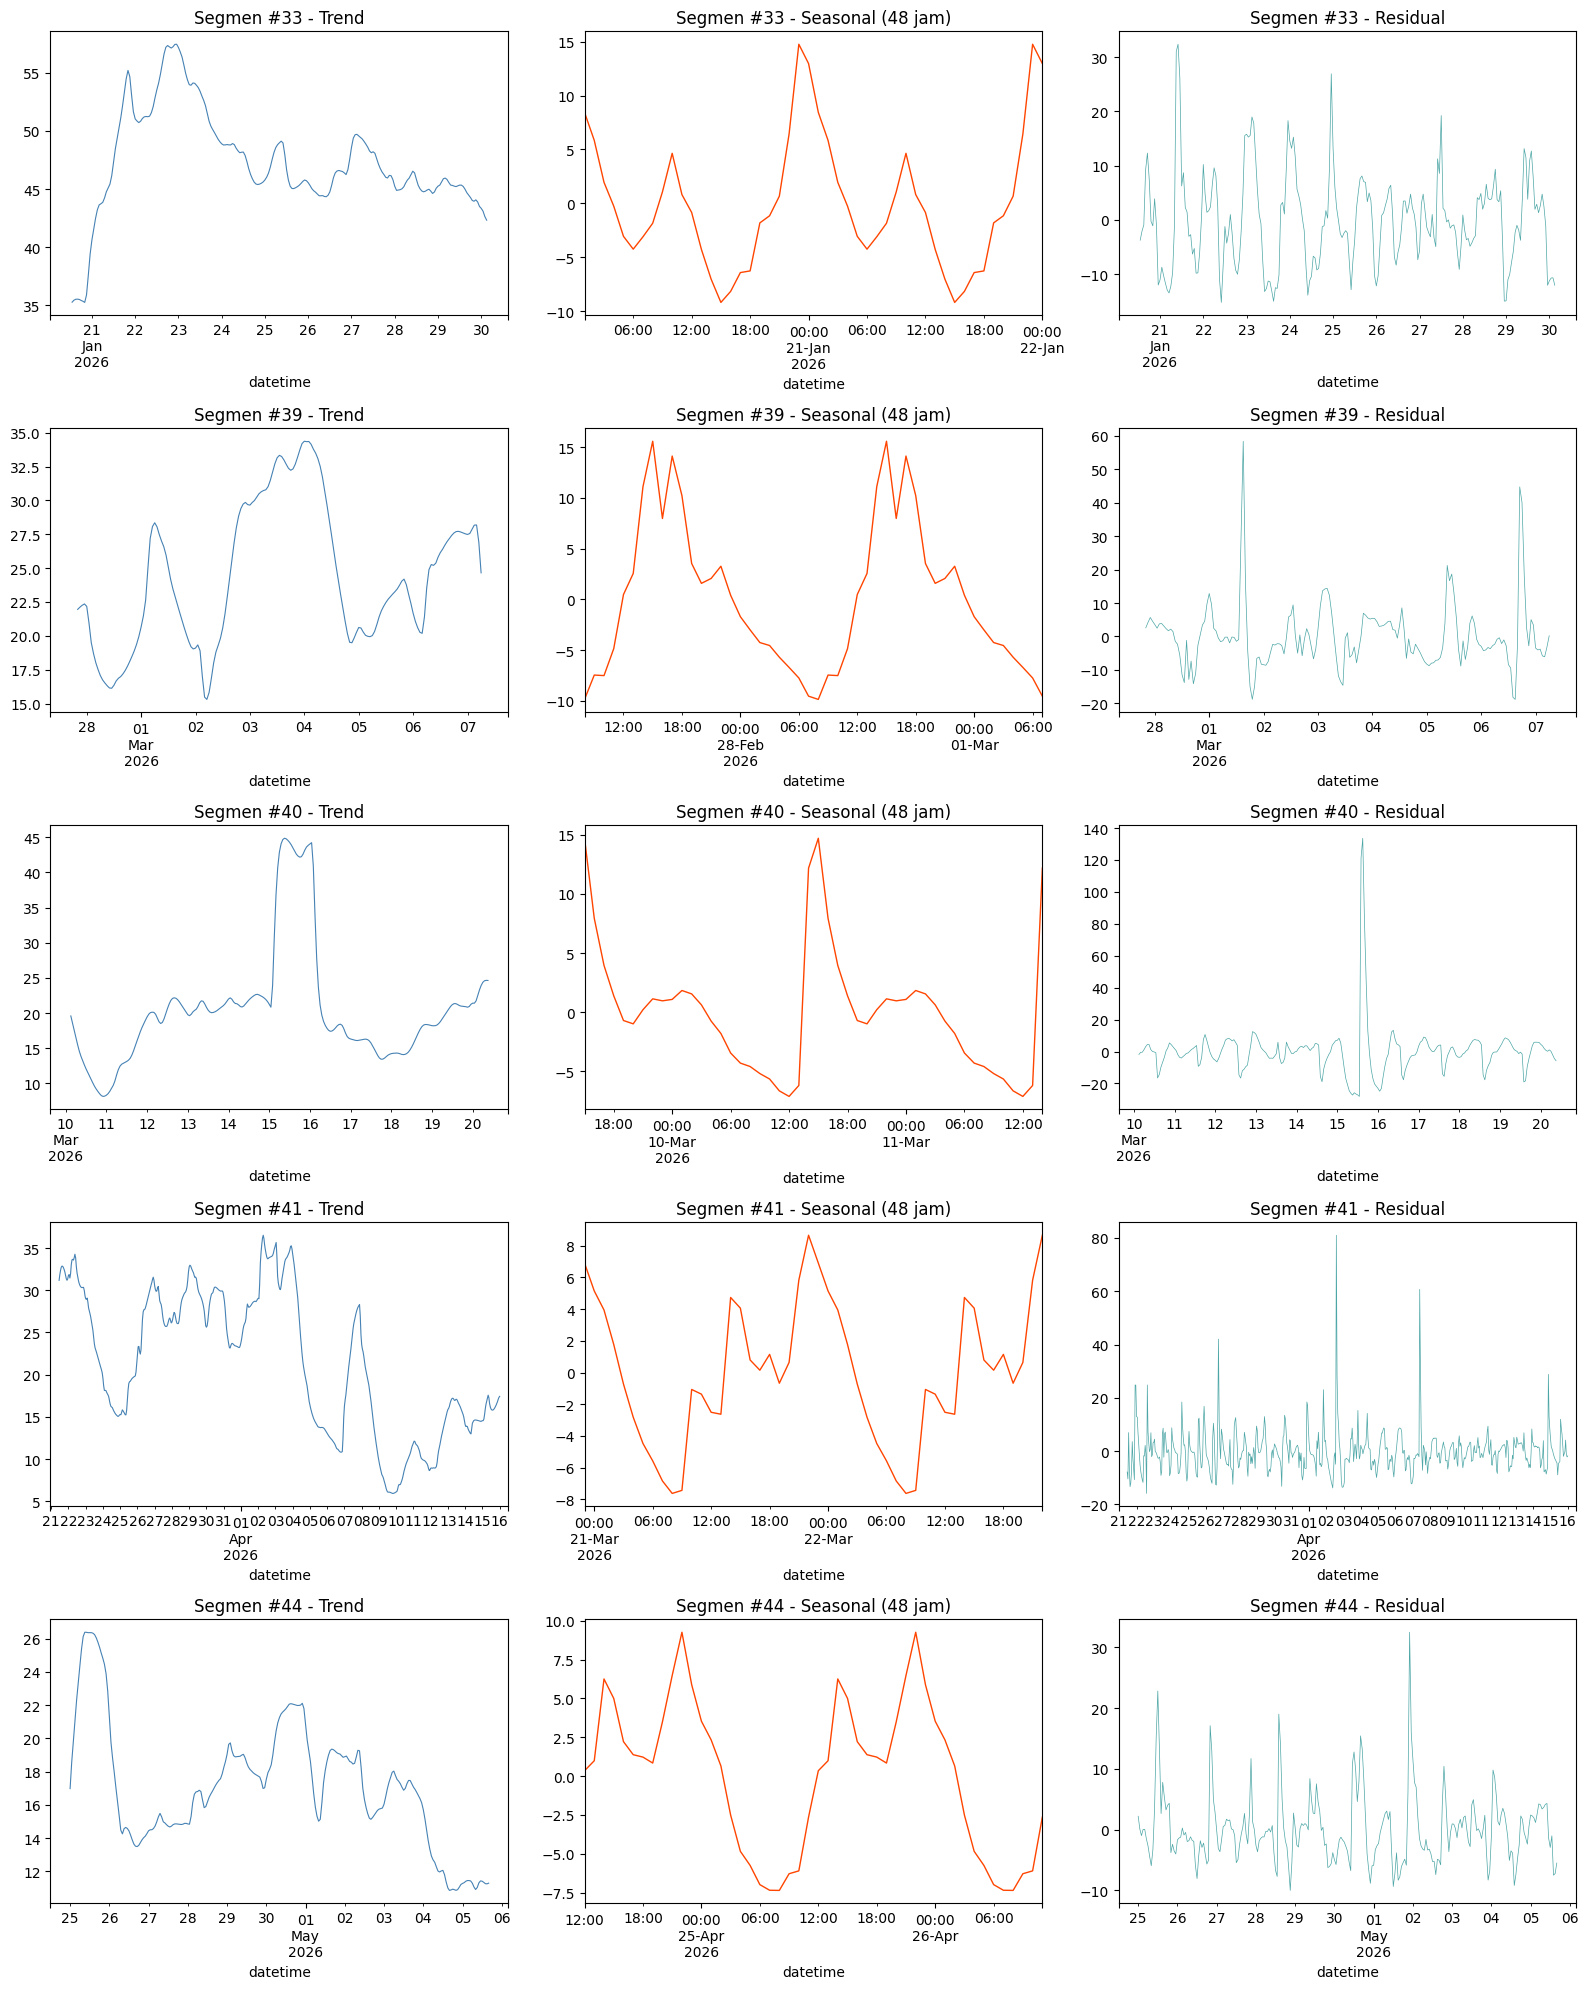

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(segmen_dfs), 3, figsize=(16, 4 * len(segmen_dfs)))
if len(segmen_dfs) == 1:
    axes = axes.reshape(1, -1)

for row, (sid, seg) in zip(axes, segmen_dfs.items()):
    ts = seg.set_index('datetime')['pm25'].asfreq('h')
    decomp = seasonal_decompose(ts.dropna(), model='additive', period=24)

    decomp.trend.plot(ax=row[0], color='steelblue', linewidth=0.8)
    row[0].set_title(f'Segmen #{sid} - Trend')

    decomp.seasonal.iloc[:48].plot(ax=row[1], color='orangered', linewidth=1)
    row[1].set_title(f'Segmen #{sid} - Seasonal (48 jam)')
    row[1].axvline(x=24, color='gray', linestyle='--', alpha=0.4)

    decomp.resid.plot(ax=row[2], color='teal', linewidth=0.5, alpha=0.7)
    row[2].set_title(f'Segmen #{sid} - Residual')

plt.tight_layout()
plt.show()

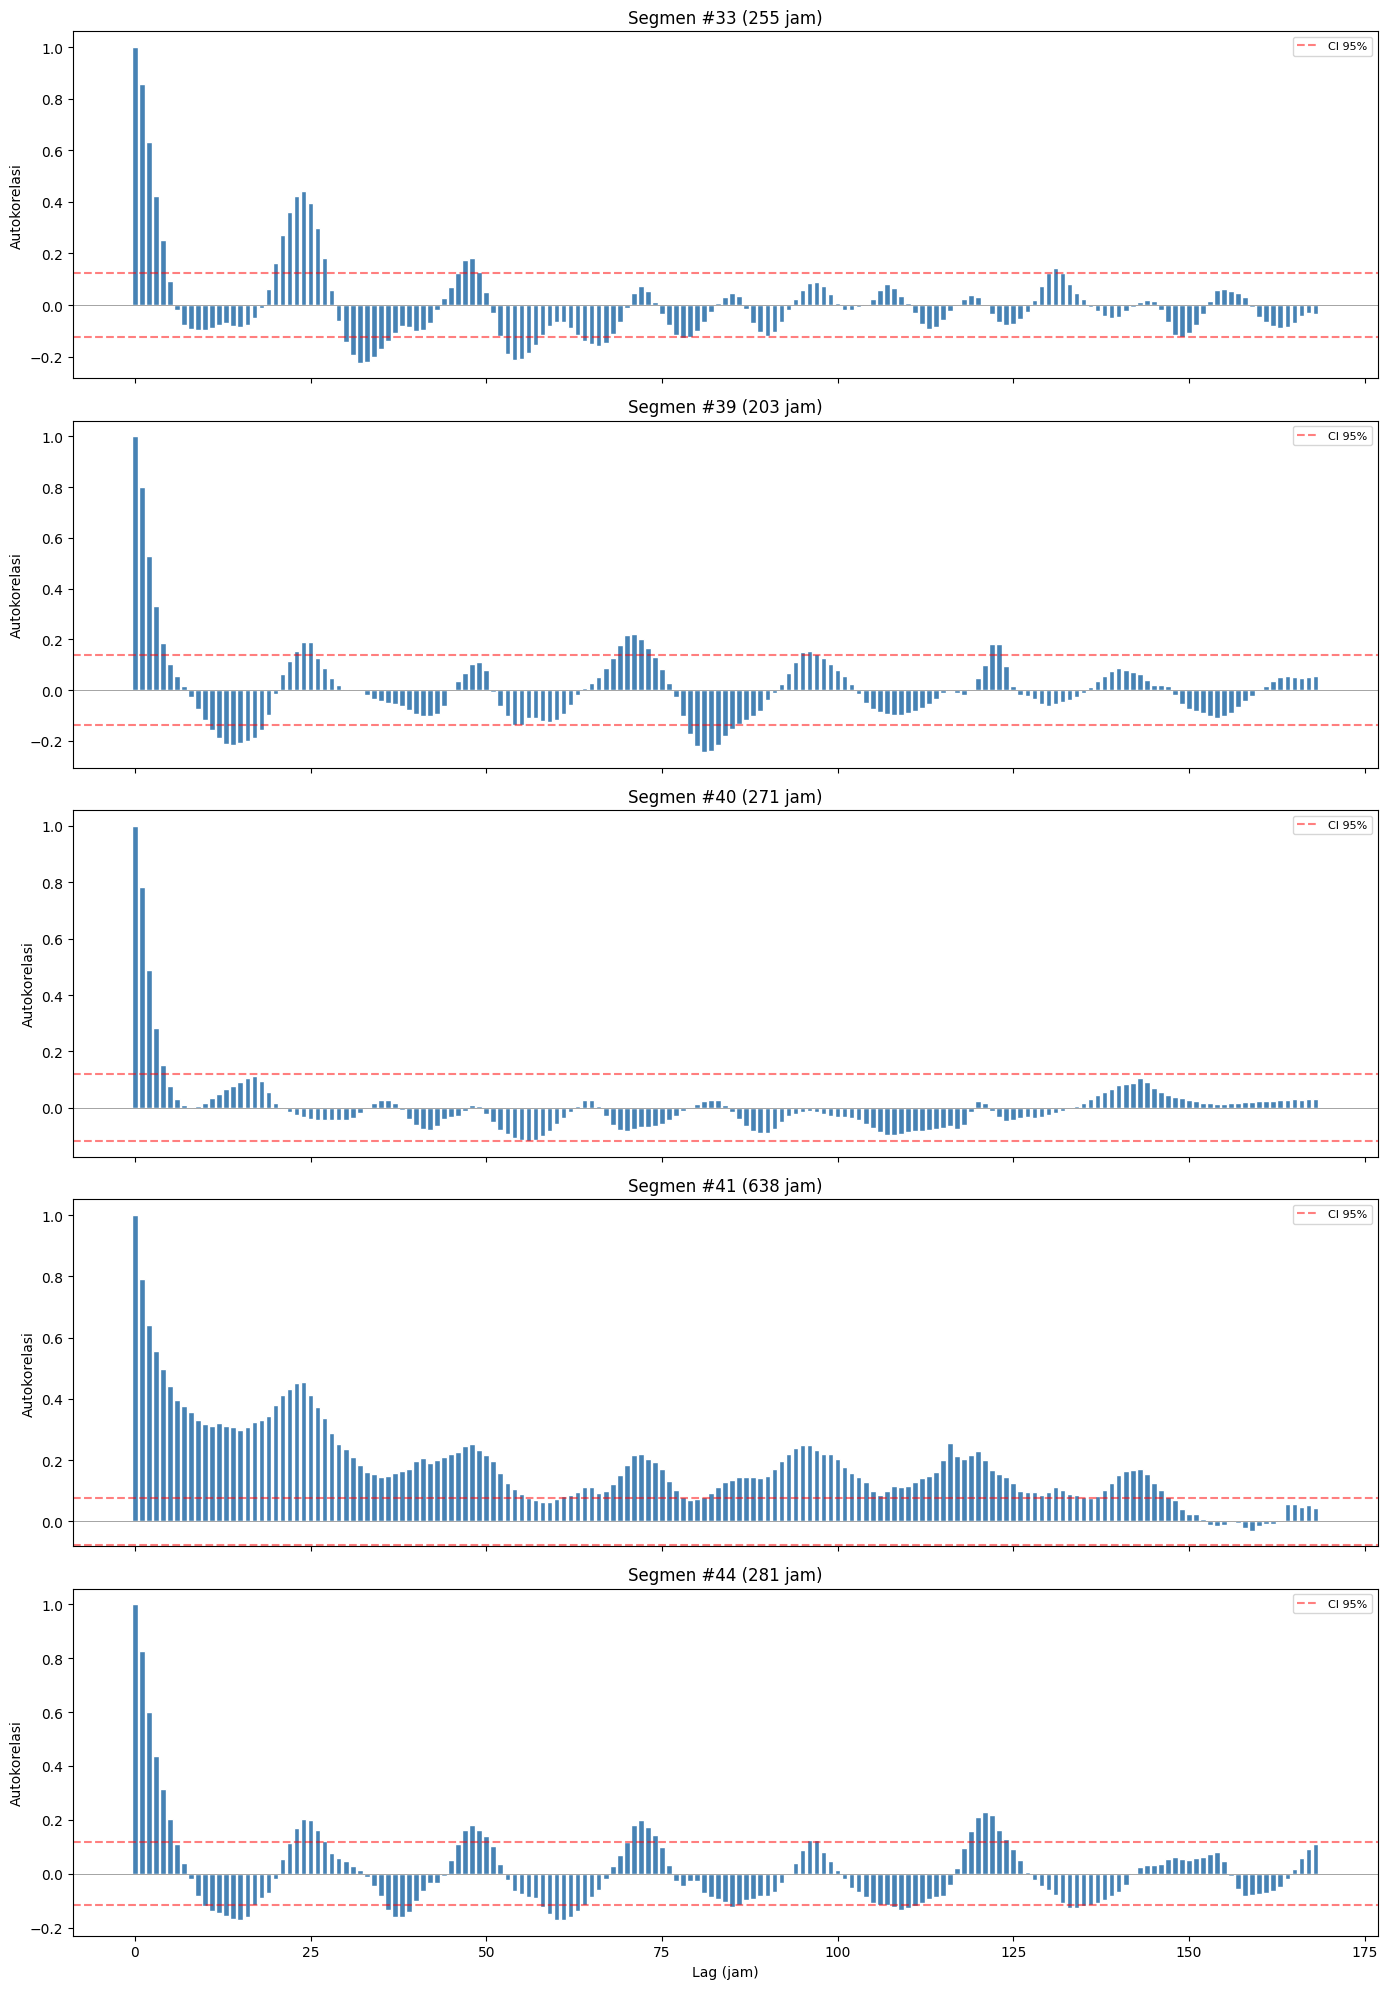

In [7]:
from statsmodels.tsa.stattools import acf
import numpy as np
import matplotlib.pyplot as plt

n_seg = len(segmen_dfs)
fig, axes = plt.subplots(n_seg, 1, figsize=(14, 4 * n_seg), sharex=True)
if n_seg == 1:
    axes = [axes]

for ax, (sid, seg) in zip(axes, segmen_dfs.items()):
    pm25 = seg['pm25'].dropna().values
    nlags = min(168, len(pm25) - 1)
    acf_values = acf(pm25, nlags=nlags)
    lags = np.arange(len(acf_values))
    
    ax.bar(lags, acf_values, width=0.8, color='steelblue', edgecolor='white')
    ax.axhline(0, color='gray', linewidth=0.5)
    ci = 1.96 / np.sqrt(len(pm25))
    ax.axhline(ci, color='red', linestyle='--', alpha=0.5, label='CI 95%')
    ax.axhline(-ci, color='red', linestyle='--', alpha=0.5)
    ax.set_ylabel('Autokorelasi')
    ax.set_title(f'Segmen #{sid} ({len(pm25)} jam)')
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Lag (jam)')
plt.tight_layout()
plt.show()

In [8]:
acf_spikes = {}

for sid, seg in segmen_dfs.items():
    pm25 = seg['pm25'].dropna().values
    nlags = min(168, len(pm25) - 1)
    acf_vals = acf(pm25, nlags=nlags)
    ci = 1.96 / np.sqrt(len(pm25))

    spike_lags = []
    for i in range(1, len(acf_vals) - 1):
        if abs(acf_vals[i]) > ci and acf_vals[i] > acf_vals[i-1] and acf_vals[i] > acf_vals[i+1]:
            spike_lags.append(i)

    acf_spikes[sid] = {'acf': acf_vals, 'spike_lags': spike_lags, 'ci': ci}

    print(f'Segmen #{sid}:')
    print(f'  CI 95%: ±{ci:.4f}')
    print(f'  Spike signifikan (lag): {spike_lags if spike_lags else "tidak ada"}')
    print()

Segmen #33:
  CI 95%: ±0.1227
  Spike signifikan (lag): [24, 48, 131]

Segmen #39:
  CI 95%: ±0.1376
  Spike signifikan (lag): [25, 71, 96, 122]

Segmen #40:
  CI 95%: ±0.1191
  Spike signifikan (lag): tidak ada

Segmen #41:
  CI 95%: ±0.0776
  Spike signifikan (lag): [12, 24, 41, 48, 65, 72, 87, 96, 99, 108, 116, 120, 128, 131, 143]

Segmen #44:
  CI 95%: ±0.1169
  Spike signifikan (lag): [24, 48, 72, 97, 121]



In [9]:
features = ['pm1', 'relativehumidity', 'temperature', 'um003']
labels = ['PM1', 'RH', 'Temp', 'UM003']

for sid, seg in segmen_dfs.items():
    seg_sorted = seg.sort_values('datetime').reset_index(drop=True)
    n = len(seg_sorted)

    print(f'Segmen #{sid} ({n} jam) - Lag Correlation terhadap PM2.5:')
    header = f'{"Lag":>4} '
    for lb in labels:
        header += f'{"|":>3} {lb:>7}'
    print(header)
    print('-' * len(header))

    for lag in range(0, 25):
        if lag == 0:
            row = f'{lag:>4} '
            for feat in features:
                r = seg_sorted[feat].corr(seg_sorted['pm25'])
                row += f'  | {r:>7.4f}'
        else:
            row = f'{lag:>4} '
            for feat in features:
                a = seg_sorted[feat].iloc[lag:].reset_index(drop=True)
                b = seg_sorted['pm25'].iloc[:-lag].reset_index(drop=True)
                r = a.corr(b)
                row += f'  | {r:>7.4f}'
        print(row)
    print()

Segmen #33 (256 jam) - Lag Correlation terhadap PM2.5:
 Lag   |     PM1  |      RH  |    Temp  |   UM003
-------------------------------------------------
   0   |  0.9946  | -0.2021  | -0.3695  |  0.9902
   1   |  0.8562  | -0.1816  | -0.3638  |  0.8533
   2   |  0.6347  | -0.0865  | -0.2966  |  0.6374
   3   |  0.4250  |  0.0012  | -0.2434  |  0.4247
   4   |  0.2524  |  0.0773  | -0.1876  |  0.2444
   5   |  0.0917  |  0.1530  | -0.1252  |  0.0784
   6   | -0.0215  |  0.2303  | -0.0589  | -0.0383
   7   | -0.0788  |  0.2574  | -0.0062  | -0.0983
   8   | -0.0944  |  0.2239  |  0.0412  | -0.1167
   9   | -0.0953  |  0.1732  |  0.0793  | -0.1175
  10   | -0.1011  |  0.0909  |  0.0784  | -0.1212
  11   | -0.0973  | -0.0125  |  0.0686  | -0.1120
  12   | -0.0871  | -0.0567  |  0.0987  | -0.0931
  13   | -0.0832  | -0.0543  |  0.1501  | -0.0795
  14   | -0.0974  | -0.0303  |  0.1983  | -0.0855
  15   | -0.1018  | -0.0152  |  0.2037  | -0.0856
  16   | -0.0908  |  0.0144  |  0.1980  | -0.

In [10]:
import numpy as np

for sid, seg in segmen_dfs.items():
    seg_sorted = seg.sort_values('datetime').reset_index(drop=True)
    pm25 = seg_sorted['pm25'].dropna().values
    n = len(pm25)

    fft_vals = np.fft.rfft(pm25 - pm25.mean())
    freqs = np.fft.rfftfreq(n, d=1)
    amp = np.abs(fft_vals) / n

    period_hours = np.where(freqs > 0, 1 / freqs, np.inf)

    mask = (period_hours >= 6) & (period_hours <= 336)
    amp_filt = amp[mask]
    period_filt = period_hours[mask]

    top_idx = np.argsort(amp_filt)[::-1][:10]

    print(f'Segmen #{sid} ({n} jam) - Top 10 Dominant Period (FFT PM2.5):')
    print(f'{"#":>3} {"Period (jam)":>15} {"Amplitude":>12} {"Keterangan":>20}')
    print('-' * 55)
    for i, idx in enumerate(top_idx, 1):
        p = period_filt[idx]
        a = amp_filt[idx]
        ket = '24 jam' if 23 <= p <= 25 else '12 jam' if 11 <= p <= 13 else '8 jam' if 7 <= p <= 9 else '6 jam' if 5.5 <= p <= 6.5 else ''
        print(f'{i:>3} {p:>15.2f} {a:>12.4f} {ket:>20}')
    print()

Segmen #33 (255 jam) - Top 10 Dominant Period (FFT PM2.5):
  #    Period (jam)    Amplitude           Keterangan
-------------------------------------------------------
  1           25.50       2.7800                     
  2           23.18       2.7636               24 jam
  3           12.14       2.6235               12 jam
  4          127.50       2.5184                     
  5           21.25       2.2889                     
  6          255.00       2.1434                     
  7           19.62       1.7952                     
  8           12.75       1.4767               12 jam
  9           85.00       1.2897                     
 10           31.88       1.2020                     

Segmen #39 (203 jam) - Top 10 Dominant Period (FFT PM2.5):
  #    Period (jam)    Amplitude           Keterangan
-------------------------------------------------------
  1           33.83       3.6800                     
  2           25.38       2.7746                     
  3          

C:\Users\Rajendra\AppData\Local\Temp\ipykernel_19888\1710345501.py:12: RuntimeWarning: divide by zero encountered in divide
  period_hours = np.where(freqs > 0, 1 / freqs, np.inf)


In [11]:
import os
out_dir = Path('processed_data')
out_dir.mkdir(exist_ok=True)

raw_cols = ['datetime', 'pm1', 'pm25', 'relativehumidity', 'temperature', 'um003']

for sid, seg in segmen_dfs.items():
    fname = out_dir / f'segmen_{sid}.csv'
    seg[raw_cols].to_csv(fname, index=False)
    print(f'Saved: {fname} ({len(seg)} rows)')

Saved: processed_data\segmen_33.csv (256 rows)
Saved: processed_data\segmen_39.csv (203 rows)
Saved: processed_data\segmen_40.csv (271 rows)


Saved: processed_data\segmen_41.csv (638 rows)
Saved: processed_data\segmen_44.csv (281 rows)
